# Generator analysis from grid data

Compare the empirical population map, its second-order generator approximation, and the full-channel spectral separation.


In [25]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

PLOT_DIR = Path('docu/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def scatter_by_sigma(ax, x, y, sigma, h_values, cmap, norm, *, label, **kwargs):
    """Use a consistent sigma marker style while colour encodes h/J."""
    if np.isclose(sigma, 1.0):
        return ax.scatter(
            x, y, c=h_values, cmap=cmap, norm=norm, marker='o',
            edgecolors='#222222', linewidths=0.7, label=label, **kwargs
        )
    if np.isclose(sigma, 2.0):
        edgecolors = plt.get_cmap(cmap)(norm(h_values))
        return ax.scatter(
            x, y, marker='s', facecolors='none', edgecolors=edgecolors,
            linewidths=1.1, label=label,
            path_effects=[pe.Stroke(linewidth=2.3, foreground='#222222'), pe.Normal()],
            **kwargs,
        )
    return ax.scatter(
        x, y, c=h_values, cmap=cmap, norm=norm, marker='D',
        edgecolors='#222222', linewidths=0.7, label=label, **kwargs
    )


## Load grid


In [26]:
grid_nr = 10
N = 4
path = Path(f'data/grid/superoperator_N{N}_grid_{grid_nr}.npz')

data = np.load(path)
grid_h_over_J = data['h_over_J'] if 'h_over_J' in data.files else data['h']

print(f'Loaded: {path}')
print(f"Grid points: {len(data['h'])}")
print('alpha values:', np.unique(data['alpha']).tolist())
print('sigma values:', np.unique(data['sigma']).tolist())


Loaded: data/grid/superoperator_N4_grid_8.npz
Grid points: 320
alpha values: [0.02, 0.04000000000000001, 0.06000000000000001, 0.08000000000000002, 0.10000000000000002, 0.12000000000000002, 0.14, 0.16, 0.18000000000000002, 0.2, 0.22, 0.24, 0.26, 0.28, 0.30000000000000004, 0.32, 0.34, 0.36, 0.38, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7, 0.75, 0.8, 0.8500000000000001, 0.9, 0.95, 1.0]
sigma values: [1.0]


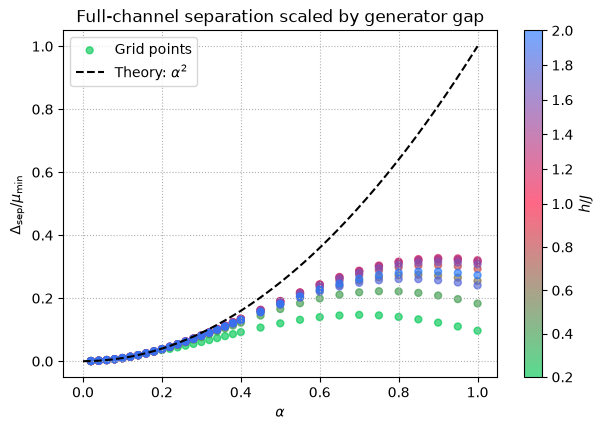

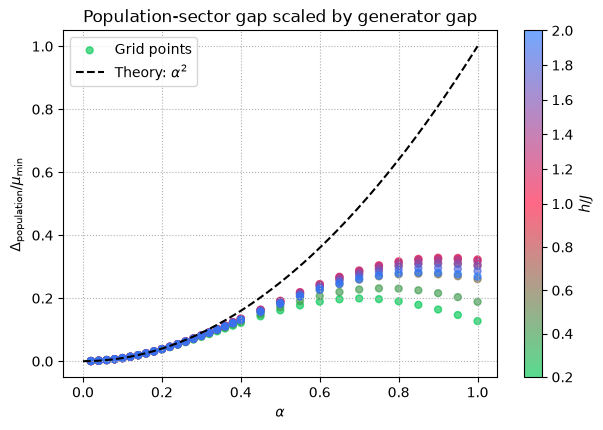

,h_over_J,alpha,generator_gap,Delta_sep,ratio
0,0.2,0.02,0.470355,0.000187,0.000398
1,0.2,0.04,0.470355,0.000746,0.001587
2,0.2,0.06,0.470355,0.001674,0.003559
3,0.2,0.08,0.470355,0.002962,0.006298
4,0.2,0.10,0.470355,0.004601,0.009782
...,...,...,...,...,...
315,2.0,0.80,0.363213,0.102108,0.281124
316,2.0,0.85,0.363213,0.103432,0.284769
317,2.0,0.90,0.363213,0.103317,0.284452
318,2.0,0.95,0.363213,0.101850,0.280414


In [27]:
import matplotlib.colors as mcolors

# The theory predicts Delta_sep / mu_min approximately equals alpha^2,
# where mu_min is the smallest positive generator decay rate.
required_keys = {'transition_generator', 'classical_populations', 'Delta_sep', 'alpha'}
missing_keys = required_keys.difference(data.files)
if missing_keys:
    raise KeyError(f'Missing required grid data: {sorted(missing_keys)}')

def generator_gap(generator):
    eigvals = np.linalg.eigvals(generator)
    stationary_index = np.argmin(np.abs(eigvals))
    nonstationary_eigvals = np.delete(eigvals, stationary_index)
    return -np.max(np.real(nonstationary_eigvals))

def population_gap(population_map):
    eigvals = np.linalg.eigvals(population_map)
    stationary_index = np.argmin(np.abs(eigvals - 1))
    nonstationary_eigvals = np.delete(eigvals, stationary_index)
    return 1 - np.max(np.abs(nonstationary_eigvals))

scaling_rows = []
for row_index, generator in enumerate(data['transition_generator']):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    delta_sep = float(data['Delta_sep'][row_index])
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_sep):
        scaling_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'sigma': float(data['sigma'][row_index]),
            'generator_gap': mu_min,
            'Delta_sep': delta_sep,
            'ratio': delta_sep / mu_min,
        })

scaling_data = pd.DataFrame(scaling_rows)
if scaling_data.empty:
    raise ValueError('No grid rows have a positive finite generator gap.')

fig, ax = plt.subplots(figsize=(7, 4.5))
h_norm = mcolors.TwoSlopeNorm(
    vmin=scaling_data['h_over_J'].min(), vcenter=1.0, vmax=scaling_data['h_over_J'].max()
)
h_cmap = mcolors.LinearSegmentedColormap.from_list(
    'h_over_J', ['#00c853', '#ff1744', '#2979ff']
)
sigma_markers = dict(zip(np.sort(scaling_data['sigma'].unique()), ('o', 's', '^', 'D', 'P')))
for sigma, marker in sigma_markers.items():
    sigma_data = scaling_data[np.isclose(scaling_data['sigma'], sigma)]
    scatter_by_sigma(
        ax, sigma_data['alpha'], sigma_data['ratio'], sigma, sigma_data['h_over_J'],
        h_cmap, h_norm, s=25, alpha=0.65, label=rf'$\sigma={sigma:g}$'
    )
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=h_norm, cmap=h_cmap), ax=ax)
colorbar.set_label(r'$h/J$')
alpha_theory = np.linspace(0, scaling_data['alpha'].max(), 200)
ax.plot(alpha_theory, alpha_theory**2, color='black', linestyle='--', label=r'Theory: $\alpha^2$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / \mu_{\min}$')
ax.set_title(r'Full-channel separation scaled by generator gap')
ax.grid(True, linestyle=':')
ax.legend()
plt.show()

population_scaling_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    delta_population = population_gap(population_map)
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_population):
        population_scaling_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'sigma': float(data['sigma'][row_index]),
            'generator_gap': mu_min,
            'population_gap': delta_population,
            'ratio': delta_population / mu_min,
        })

population_scaling_data = pd.DataFrame(population_scaling_rows)
if population_scaling_data.empty:
    raise ValueError('No grid rows have a positive finite population-sector generator gap.')

fig, ax = plt.subplots(figsize=(7, 4.5))
for sigma, marker in sigma_markers.items():
    sigma_data = population_scaling_data[np.isclose(population_scaling_data['sigma'], sigma)]
    scatter_by_sigma(
        ax, sigma_data['alpha'], sigma_data['ratio'], sigma, sigma_data['h_over_J'],
        h_cmap, h_norm, s=25, alpha=0.65, label=rf'$\sigma={sigma:g}$'
    )
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=h_norm, cmap=h_cmap), ax=ax)
colorbar.set_label(r'$h/J$')
ax.plot(alpha_theory, alpha_theory**2, color='black', linestyle='--', label=r'Theory: $\alpha^2$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\Delta_{\mathrm{population}} / \mu_{\min}$')
ax.set_title(r'Population-sector gap scaled by generator gap')
ax.grid(True, linestyle=':')
ax.legend()
plt.show()

scaling_data


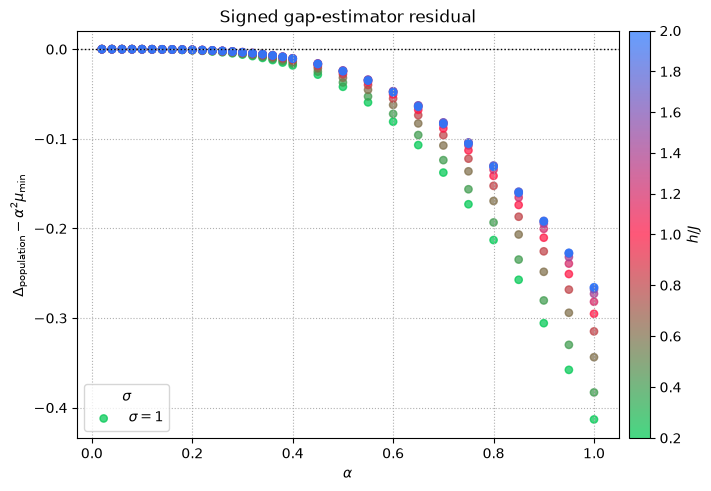

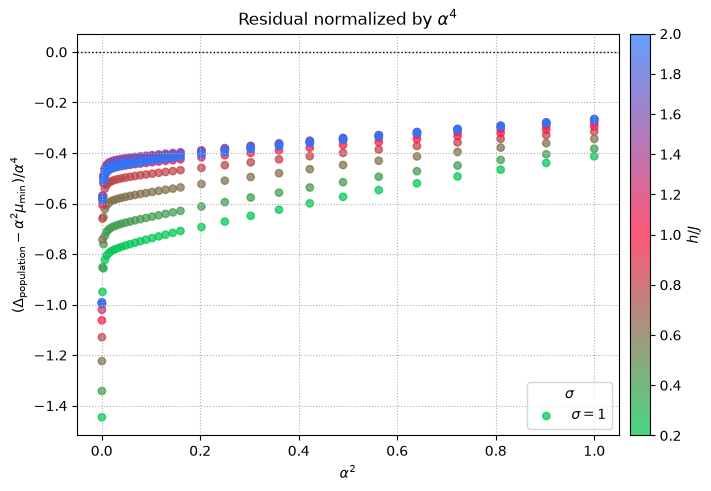

,h_over_J,alpha,sigma,observed_gap,estimated_gap,residual,residual_over_alpha4
0,0.2,0.02,1.0,0.000188,0.000188,-2.313461e-07,-1.445913
1,0.2,0.04,1.0,0.000750,0.000753,-2.430851e-06,-0.949551
2,0.2,0.06,1.0,0.001682,0.001693,-1.110315e-05,-0.856724
3,0.2,0.08,1.0,0.002977,0.003010,-3.371681e-05,-0.823164
4,0.2,0.10,1.0,0.004623,0.004704,-8.064593e-05,-0.806459
...,...,...,...,...,...,...,...
315,2.0,0.80,1.0,0.101208,0.232456,-1.312485e-01,-0.320431
316,2.0,0.85,1.0,0.102309,0.262421,-1.601119e-01,-0.306724
317,2.0,0.90,1.0,0.101986,0.294202,-1.922167e-01,-0.292969
318,2.0,0.95,1.0,0.100348,0.327800,-2.274517e-01,-0.279251


In [30]:
# All-grid comparison of the population-sector gap with the alpha^2 estimator.
import matplotlib.colors as mcolors

residual_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    observed_gap = population_gap(population_map)
    estimated_gap = alpha**2 * mu_min
    if np.isfinite(observed_gap) and np.isfinite(estimated_gap):
        residual_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'sigma': float(data['sigma'][row_index]),
            'observed_gap': observed_gap,
            'estimated_gap': estimated_gap,
            'residual': observed_gap - estimated_gap,
            'residual_over_alpha4': (observed_gap - estimated_gap) / alpha**4,
        })

residual_data = pd.DataFrame(residual_rows)
if residual_data.empty:
    raise ValueError('No finite population-sector gaps are available.')

h_norm = mcolors.TwoSlopeNorm(
    vmin=residual_data['h_over_J'].min(), vcenter=1.0, vmax=residual_data['h_over_J'].max()
)
h_cmap = mcolors.LinearSegmentedColormap.from_list(
    'h_over_J', ['#00c853', '#ff1744', '#2979ff']
)
sigma_markers = dict(zip(np.sort(residual_data['sigma'].unique()), ['o', 's', '^', 'D', 'P']))

fig, residual_ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
for sigma, marker in sigma_markers.items():
    sigma_data = residual_data[residual_data['sigma'] == sigma]
    points = scatter_by_sigma(
        residual_ax, sigma_data['alpha'], sigma_data['residual'], sigma, sigma_data['h_over_J'],
        h_cmap, h_norm, s=28, alpha=0.72, label=rf'$\sigma={sigma:g}$'
    )
residual_ax.axhline(0, color='black', linewidth=1, linestyle=':')
residual_ax.set_xlabel(r'$\alpha$')
residual_ax.set_ylabel(r'$\Delta_{\mathrm{population}} - \alpha^2\mu_{\min}$')
residual_ax.set_title('Signed gap-estimator residual')
residual_ax.grid(True, linestyle=':')
residual_ax.legend(title=r'$\sigma$')

colorbar = fig.colorbar(points, ax=residual_ax, pad=0.02)
colorbar.set_label(r'$h/J$')
plt.show()

fig, normalized_ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
for sigma, marker in sigma_markers.items():
    sigma_data = residual_data[residual_data['sigma'] == sigma]
    points = scatter_by_sigma(
        normalized_ax, sigma_data['alpha']**2, sigma_data['residual_over_alpha4'], sigma,
        sigma_data['h_over_J'], h_cmap, h_norm, s=28, alpha=0.72, label=rf'$\sigma={sigma:g}$'
    )

normalized_ax.axhline(0, color='black', linewidth=1, linestyle=':')
normalized_ax.set_xlabel(r'$\alpha^2$')
normalized_ax.set_ylabel(r'$(\Delta_{\mathrm{population}} - \alpha^2\mu_{\min}) / \alpha^4$')
normalized_ax.set_title(r'Residual normalized by $\alpha^4$')
normalized_ax.grid(True, linestyle=':')
normalized_ax.legend(title=r'$\sigma$')
colorbar = fig.colorbar(points, ax=normalized_ax, pad=0.02)
colorbar.set_label(r'$h/J$')
plt.show()

# The alpha^4 factors cancel in the sigma=2 / sigma=1 quotient, so this
# single figure represents both the signed and alpha^4-normalized residual ratios.
required_sigmas = {1.0, 2.0}
available_sigmas = set(np.round(residual_data['sigma'].unique(), 12))
if not required_sigmas.issubset(available_sigmas):
    raise ValueError('The residual ratio plot requires sigma=1 and sigma=2 data.')

ratio_rows = []
for h_over_J in np.sort(residual_data['h_over_J'].unique()):
    h_data = residual_data[np.isclose(residual_data['h_over_J'], h_over_J)].copy()
    # Source grids can represent the same alpha with tiny floating-point differences.
    h_data['alpha_key'] = h_data['alpha'].round(12)
    sigma_one = h_data[np.isclose(h_data['sigma'], 1.0)].set_index('alpha_key')
    sigma_two = h_data[np.isclose(h_data['sigma'], 2.0)].set_index('alpha_key')
    paired = sigma_one[['alpha', 'residual']].join(
        sigma_two[['residual']], how='inner', lsuffix='_sigma1', rsuffix='_sigma2'
    )
    denominator_floor = 1e-12
    paired = paired[paired['residual_sigma1'].abs() > denominator_floor]
    ratio_rows.extend({
        'h_over_J': h_over_J,
        'alpha': row.alpha,
        'residual_ratio': row.residual_sigma2 / row.residual_sigma1,
    } for row in paired.itertuples())

residual_ratio_data = pd.DataFrame(ratio_rows)
if residual_ratio_data.empty:
    raise ValueError('No matched, nonzero residual pairs are available for the sigma ratio plot.')

fig, ratio_ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
ratio_colors = plt.cm.turbo(np.linspace(0.05, 0.95, residual_ratio_data['h_over_J'].nunique()))
for (h_over_J, curve_data), color in zip(residual_ratio_data.groupby('h_over_J'), ratio_colors):
    curve_data = curve_data.sort_values('alpha')
    ratio_ax.plot(
        curve_data['alpha'], curve_data['residual_ratio'], marker='o', markersize=3,
        linewidth=1.4, color=color, label=rf'$h/J={h_over_J:g}$'
    )
ratio_ax.set_xlabel(r'$\alpha$')
ratio_ax.set_ylabel(r'$R_{\sigma=2} / R_{\sigma=1}$')
ratio_ax.set_title(r'Signed residual ratio: $\sigma=2$ divided by $\sigma=1$')
ratio_ax.grid(True, linestyle=':')
ratio_ax.legend()
plt.show()

residual_data


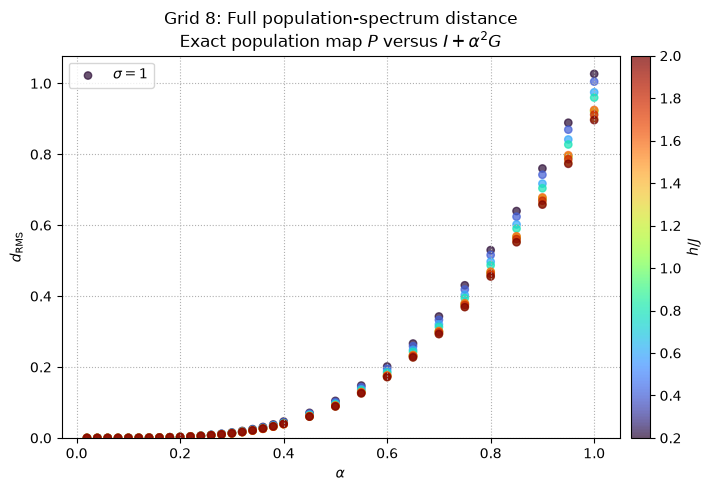

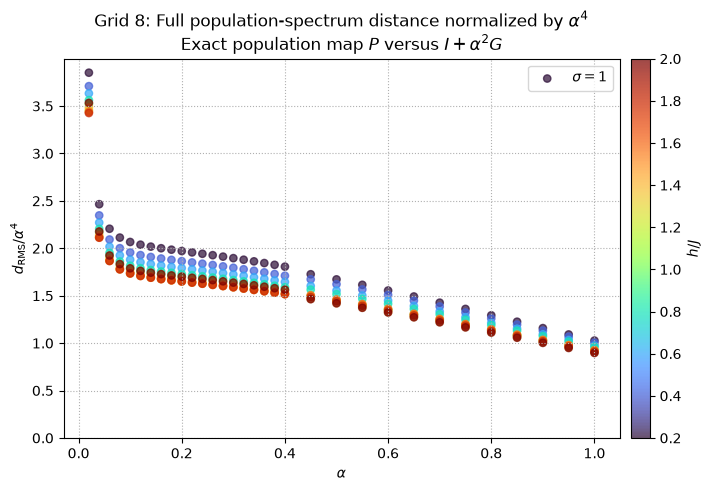

,h_over_J,alpha,sigma,spectral_distance,spectral_distance_over_alpha4
0,0.2,0.02,1.0,6.162391e-07,3.851494
1,0.2,0.04,1.0,6.309794e-06,2.464763
2,0.2,0.06,1.0,2.859048e-05,2.206055
3,0.2,0.08,1.0,8.653726e-05,2.112726
4,0.2,0.10,1.0,2.066423e-04,2.066423
...,...,...,...,...,...
315,2.0,0.80,1.0,4.552477e-01,1.111445
316,2.0,0.85,1.0,5.517310e-01,1.056943
317,2.0,0.90,1.0,6.578501e-01,1.002667
318,2.0,0.95,1.0,7.729358e-01,0.948962


In [31]:
# Full population spectra: exact population map P versus I + alpha^2 G.
from scipy.optimize import linear_sum_assignment
from itertools import cycle
import matplotlib.colors as mcolors

def population_spectral_distance(observed_eigenvalues, predicted_eigenvalues):
    """RMS distance under optimal one-to-one matching, including multiplicities."""
    squared_distances = np.abs(
        observed_eigenvalues[:, None] - predicted_eigenvalues[None, :]
    )**2
    observed_indices, predicted_indices = linear_sum_assignment(squared_distances)
    return np.sqrt(squared_distances[observed_indices, predicted_indices].mean())

spectral_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    if not (
        np.isfinite(alpha)
        and np.all(np.isfinite(population_map))
        and np.all(np.isfinite(generator))
    ):
        continue
    observed_spectrum = np.linalg.eigvals(population_map)
    predicted_spectrum = 1 + alpha**2 * np.linalg.eigvals(generator)
    # Keep all modes, including the stationary eigenvalue near 1.
    distance = population_spectral_distance(observed_spectrum, predicted_spectrum)
    spectral_rows.append({
        'h_over_J': float(grid_h_over_J[row_index]),
        'alpha': alpha,
        'sigma': float(data['sigma'][row_index]),
        'spectral_distance': distance,
        'spectral_distance_over_alpha4': distance / alpha**4 if alpha != 0 else np.nan,
    })

population_spectral_data = pd.DataFrame(spectral_rows)
if population_spectral_data.empty:
    raise ValueError('No finite population/generator spectra are available.')

spectral_h_norm = mcolors.Normalize(
    vmin=population_spectral_data['h_over_J'].min(),
    vmax=population_spectral_data['h_over_J'].max(),
)
spectral_sigma_markers = dict(zip(
    np.sort(population_spectral_data['sigma'].unique()),
    cycle(['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']),
))
for distance_column, ylabel, title in [
    ('spectral_distance', r'$d_{\mathrm{RMS}}$', 'Full population-spectrum distance'),
    ('spectral_distance_over_alpha4', r'$d_{\mathrm{RMS}} / \alpha^4$',
     r'Full population-spectrum distance normalized by $\alpha^4$'),
]:
    fig, spectral_ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
    for sigma, marker in spectral_sigma_markers.items():
        sigma_spectra = population_spectral_data[
            (population_spectral_data['sigma'] == sigma)
            & np.isfinite(population_spectral_data[distance_column])
        ]
        spectral_points = scatter_by_sigma(
            spectral_ax, sigma_spectra['alpha'], sigma_spectra[distance_column], sigma,
            sigma_spectra['h_over_J'], 'turbo', spectral_h_norm, s=28, alpha=0.72,
            label=rf'$\sigma={sigma:g}$',
        )
    if distance_column == 'spectral_distance':
        spectral_alpha_reference = np.linspace(
            0, population_spectral_data['alpha'].max(), 300
        )
        #spectral_ax.plot(
        #    spectral_alpha_reference, spectral_alpha_reference**2,
        #    color='black', linestyle='--', label=r'Reference: $\alpha^2$',
        #)
    spectral_ax.set_xlabel(r'$\alpha$')
    spectral_ax.set_ylabel(ylabel)
    spectral_ax.set_title(f'Grid {grid_nr}: ' + title + '\n'
                          + r'Exact population map $P$ versus $I+\alpha^2G$')
    spectral_ax.set_ylim(bottom=0)
    spectral_ax.grid(True, linestyle=':')
    spectral_ax.legend()
    fig.colorbar(spectral_points, ax=spectral_ax, pad=0.02).set_label(r'$h/J$')
    plt.show()

population_spectral_data


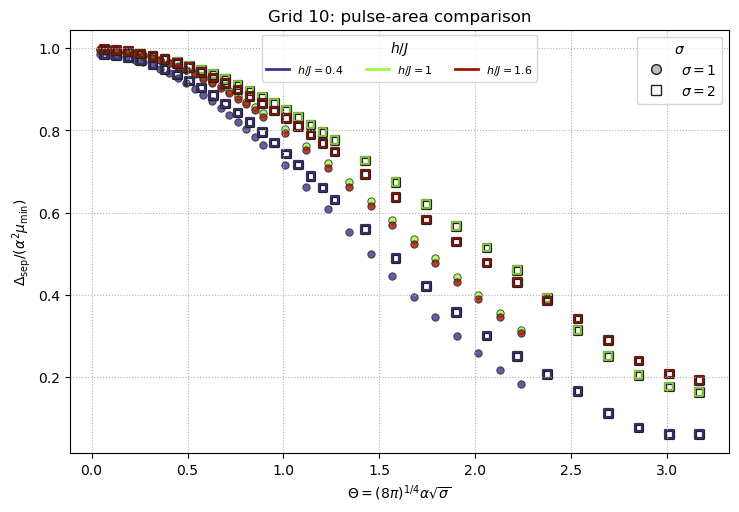

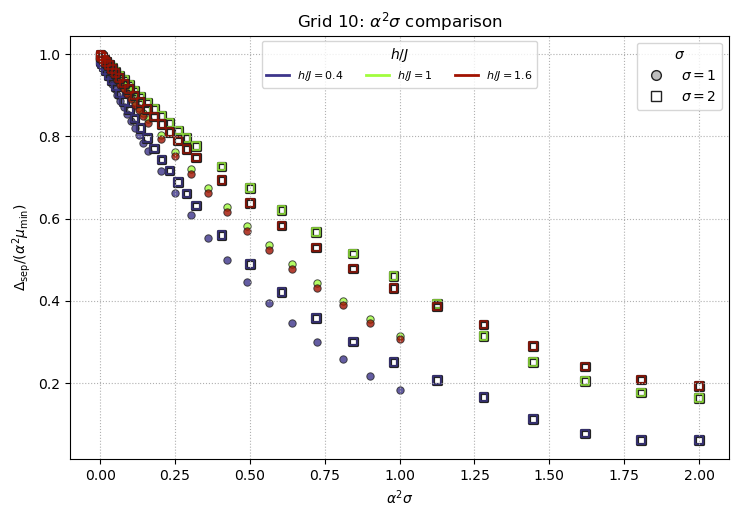

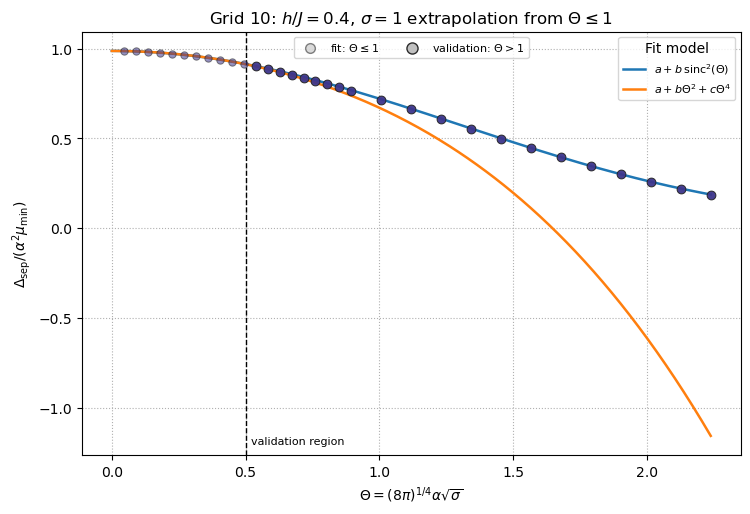

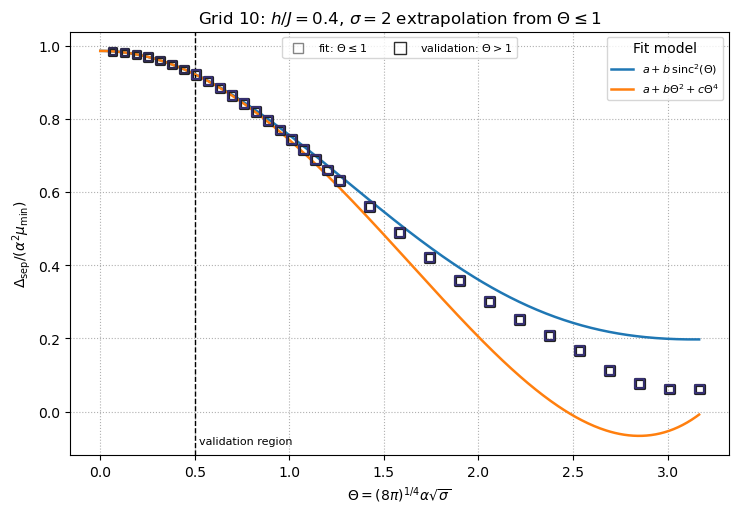

,sigma,model,a,b,c,validation_RMSE,validation_R_squared
0,1.0,"$a+b\,\mathrm{sinc}^2(\Theta)$",0.0757,0.9114,NaN,0.0024,0.9999
1,1.0,$a+b\Theta^2+c\Theta^4$,0.9867,-0.2883,-0.0277,0.4923,-3.2206
2,2.0,"$a+b\,\mathrm{sinc}^2(\Theta)$",0.1972,0.7893,NaN,0.0567,0.9635
3,2.0,$a+b\Theta^2+c\Theta^4$,0.9865,-0.2595,0.0160,0.0879,0.9124


In [54]:
# Finite-pulse comparisons for the grid loaded above.
import matplotlib.patheffects as pe
pulse_area_coefficient = (8 * np.pi)**0.25
curve_rows = []
for row_index, generator in enumerate(data['transition_generator']):
    alpha = float(data['alpha'][row_index])
    sigma = float(data['sigma'][row_index])
    mu_min = generator_gap(generator)
    delta_sep = float(data['Delta_sep'][row_index])
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_sep):
        theta = pulse_area_coefficient * alpha * np.sqrt(sigma)
        curve_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'sigma': sigma,
            'theta': theta,
            'ratio': delta_sep / (alpha**2 * mu_min),
        })

curve_fit_data = pd.DataFrame(curve_rows)
h_values = np.sort(curve_fit_data['h_over_J'].unique())
h_colors = dict(zip(h_values, plt.cm.turbo(np.linspace(0.05, 0.95, len(h_values)))))
sigma_markers = {1.0: 'o', 2.0: 's'}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for h_over_J, color in h_colors.items():
    for sigma, marker in sigma_markers.items():
        plot_data = curve_fit_data[
            np.isclose(curve_fit_data['h_over_J'], h_over_J)
            & np.isclose(curve_fit_data['sigma'], sigma)
        ]
        if sigma == 1.0:
            ax.scatter(
                plot_data['theta'], plot_data['ratio'], marker=marker, facecolors=color,
                edgecolors='#222222', linewidths=0.7, s=28, alpha=0.8
            )
        else:
            ax.scatter(
                plot_data['theta'], plot_data['ratio'], marker=marker, facecolors='none',
                edgecolors=color, linewidths=1.1, s=30, alpha=0.9,
                path_effects=[pe.Stroke(linewidth=2.3, foreground='#222222'), pe.Normal()]
            )

ax.set_xlabel(r'$\Theta = (8\pi)^{1/4}\alpha\sqrt{\sigma}$')
ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / (\alpha^2\mu_{\min})$')
ax.set_title(f'Grid {grid_nr}: pulse-area comparison')
ax.grid(True, linestyle=':')
sigma_handles = [
    plt.Line2D([], [], marker='o', color='none', markerfacecolor='#bdbdbd',
               markeredgecolor='#222222', markersize=7, label=r'$\sigma=1$'),
    plt.Line2D([], [], marker='s', color='none', markerfacecolor='none',
               markeredgecolor='#222222', markersize=7, label=r'$\sigma=2$'),
]
h_handles = [
    plt.Line2D([], [], color=color, linewidth=2, label=rf'$h/J={h_over_J:g}$')
    for h_over_J, color in h_colors.items()
]
sigma_legend = ax.legend(handles=sigma_handles, title=r'$\sigma$', loc='upper right')
ax.add_artist(sigma_legend)
ax.legend(handles=h_handles, title=r'$h/J$', loc='upper center', ncol=3, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for h_over_J, color in h_colors.items():
    for sigma, marker in sigma_markers.items():
        plot_data = curve_fit_data[
            np.isclose(curve_fit_data['h_over_J'], h_over_J)
            & np.isclose(curve_fit_data['sigma'], sigma)
        ]
        if sigma == 1.0:
            ax.scatter(
                plot_data['alpha']**2 * plot_data['sigma'], plot_data['ratio'],
                marker=marker, facecolors=color, edgecolors='#222222', linewidths=0.7,
                s=28, alpha=0.8
            )
        else:
            ax.scatter(
                plot_data['alpha']**2 * plot_data['sigma'], plot_data['ratio'],
                marker=marker, facecolors='none', edgecolors=color, linewidths=1.1,
                s=30, alpha=0.9,
                path_effects=[pe.Stroke(linewidth=2.3, foreground='#222222'), pe.Normal()]
            )

ax.set_xlabel(r'$\alpha^2\sigma$')
ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / (\alpha^2\mu_{\min})$')
ax.set_title(rf'Grid {grid_nr}: $\alpha^2\sigma$ comparison')
ax.grid(True, linestyle=':')
sigma_legend = ax.legend(handles=sigma_handles, title=r'$\sigma$', loc='upper right')
ax.add_artist(sigma_legend)
ax.legend(handles=h_handles, title=r'$h/J$', loc='upper center', ncol=3, fontsize=8)
plt.show()

# Exploratory held-out extrapolation test at one field.
fit_h_over_J = 0.4
validation_boundary = 0.5
fit_data = curve_fit_data[np.isclose(curve_fit_data['h_over_J'], fit_h_over_J)].copy()
model_designs = {
    r'$a+b\,\mathrm{sinc}^2(\Theta)$': lambda theta: np.column_stack([
        np.ones(len(theta)), np.sinc(theta / np.pi)**2
    ]),
    r'$a+b\Theta^2+c\Theta^4$': lambda theta: np.column_stack([
        np.ones(len(theta)), theta**2, theta**4
    ]),
}

fit_summary = []
model_colors = plt.cm.tab10(np.arange(len(model_designs)))
for sigma, marker in sigma_markers.items():
    sigma_data = fit_data[np.isclose(fit_data['sigma'], sigma)].copy()
    train_data = sigma_data[sigma_data['theta'] <= validation_boundary]
    validation_data = sigma_data[sigma_data['theta'] > validation_boundary]
    if train_data.empty or validation_data.empty:
        raise ValueError('The extrapolation test requires points on both sides of Theta=1.')

    fig, extrapolation_ax = plt.subplots(figsize=(8.5, 5.5))
    theta_line = np.linspace(0, sigma_data['theta'].max(), 400)
    for (model_name, design), color in zip(model_designs.items(), model_colors):
        train_design = design(train_data['theta'].to_numpy())
        coefficients = np.linalg.lstsq(train_design, train_data['ratio'], rcond=None)[0]
        validation_prediction = design(validation_data['theta'].to_numpy()) @ coefficients
        validation_residual = validation_data['ratio'].to_numpy() - validation_prediction
        validation_rmse = np.sqrt(np.mean(validation_residual**2))
        validation_total = np.sum((validation_data['ratio'] - validation_data['ratio'].mean())**2)
        validation_r2 = (
            1 - np.sum(validation_residual**2) / validation_total
            if validation_total > 0 else np.nan
        )
        extrapolation_ax.plot(
            theta_line, design(theta_line) @ coefficients, color=color, linewidth=1.8,
            label=model_name
        )
        fit_summary.append({
            'sigma': sigma, 'model': model_name, 'a': coefficients[0], 'b': coefficients[1],
            'c': coefficients[2] if len(coefficients) > 2 else np.nan,
            'validation_RMSE': validation_rmse, 'validation_R_squared': validation_r2,
        })

    if sigma == 1.0:
        style = dict(marker=marker, facecolors=h_colors[fit_h_over_J], edgecolors='#222222', linewidths=0.7)
    else:
        style = dict(
            marker=marker, facecolors='none', edgecolors=h_colors[fit_h_over_J], linewidths=1.1,
            path_effects=[pe.Stroke(linewidth=2.3, foreground='#222222'), pe.Normal()]
        )
    extrapolation_ax.scatter(train_data['theta'], train_data['ratio'], s=28, alpha=0.55, zorder=3, **style)
    extrapolation_ax.scatter(validation_data['theta'], validation_data['ratio'], s=40, alpha=0.95, zorder=3, **style)
    extrapolation_ax.axvline(validation_boundary, color='black', linewidth=1, linestyle='--')
    extrapolation_ax.text(validation_boundary+0.02, 0.02, 'validation region', transform=extrapolation_ax.get_xaxis_transform(),
                          ha='left', va='bottom', fontsize=8)
    extrapolation_ax.set_xlabel(r'$\Theta = (8\pi)^{1/4}\alpha\sqrt{\sigma}$')
    extrapolation_ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / (\alpha^2\mu_{\min})$')
    extrapolation_ax.set_title(rf'Grid {grid_nr}: $h/J={fit_h_over_J:g}$, $\sigma={sigma:g}$ extrapolation from $\Theta \leq 1$')
    extrapolation_ax.grid(True, linestyle=':')
    model_legend = extrapolation_ax.legend(title='Fit model', loc='upper right', fontsize=8)
    extrapolation_ax.add_artist(model_legend)
    extrapolation_ax.legend(
        handles=[
            plt.Line2D([], [], marker=marker, color='none', markerfacecolor='#bdbdbd' if sigma == 1 else 'none',
                       markeredgecolor='#222222', alpha=0.55, markersize=7, label=r'fit: $\Theta \leq 1$'),
            plt.Line2D([], [], marker=marker, color='none', markerfacecolor='#bdbdbd' if sigma == 1 else 'none',
                       markeredgecolor='#222222', alpha=0.95, markersize=8, label=r'validation: $\Theta > 1$'),
        ],
        loc='upper center', ncol=2, fontsize=8
    )
    plt.show()

pd.DataFrame(fit_summary).round(4)
